In [1]:
import numpy as np
import numpy.lib.recfunctions as recfun
from pathlib import Path
from plyfile import PlyData, PlyElement
import matplotlib.pyplot as plt

from matplotlib import cm

import random
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics.classification import MulticlassF1Score, MulticlassPrecision, MulticlassRecall, MulticlassJaccardIndex, BinaryAccuracy, BinaryMatthewsCorrCoef

import torchsummary
import time

In [2]:
def set_seed(seed=42):
    # Python & OS
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch CPU
    torch.manual_seed(seed)
    
    # PyTorch GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    # Backend CUDA (CuDNN)
    #torch.backends.cudnn.deterministic = True
    #torch.backends.cudnn.benchmark = True
    
    #print(f"Global seed fixed on {seed} (Deterministic CuDNN activated)")
    print(f"Global seed fixed on {seed}")

In [3]:
set_seed()

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

Global seed fixed on 42


In [4]:
# We start with loading the .ssm data in this cell to keep the data loaded in the following
def load_full_dataset(dataset='Train'):
    # 1) Path Definition
    # base directory for the chosen dataset
    base_path = Path('../data/Challenge-ABC') / dataset
    if not base_path.exists(): # verification
        print(f"Error: Dataset folder {base_path} not found, check 'dataset' argument.")
        return None
    ssm_dir = base_path / 'SSM_Challenge-ABC'
    lb_dir = base_path / 'lb'

    X_list = []
    y_list = []

    ssm_files = list(ssm_dir.glob('*.ssm'))
    total_files = len(ssm_files)

    for i, ssm_file in enumerate(ssm_files, 1):
        file_id = ssm_file.stem
        lb_file = lb_dir / f"{file_id}.lb"

        # check that the labels file exists
        if not lb_file.exists():
            print(f"Error: Didn't find labels file for {file_id}.ply -> ignored.")
            continue

        features = np.loadtxt(ssm_file, skiprows=5, dtype='float32').reshape(-1, 20, 16)
        labels = np.loadtxt(lb_file, dtype='int')

        if len(labels) == len(features):
            X_list.append(features)
            y_list.append(labels)
        else:
            print(f"Error: Dimension error for {file_id} -> ignored.")

        if i % 20 == 0:
            print(f"Loading : {i}/{total_files} files...")

    X = np.vstack(X_list)
    y = np.concatenate(y_list)    
    
    return X, y


X_train, y_train, X_val, y_val = None, None, None, None

# save the datasets in a .npz file for faster loading in the future
npz_file = Path("../data/Challenge-ABC/datasets.npz")
if npz_file.exists():
    print("Loading datasets from .npz file...")
    data = np.load(npz_file)
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
else:
    print("Loading datasets from .ssm and .lb files...")
    print("Train dataset loading...")
    X_train, y_train = load_full_dataset('Train')
    print("\nValidation dataset loading...")
    X_val, y_val = load_full_dataset('Validation')
    np.savez(npz_file, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)
    print("npz file saved for future use.")

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

Loading datasets from .npz file...
X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)
X_val shape: (690211, 20, 16)
y_val shape: (690211,)


In [5]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

print(type(X_train))
print(type(y_train))
print(type(X_val))
print(type(y_val))

# Transform numpy's arrays to torch tensors:
X_train = torch.tensor(X_train).to(torch.float)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val).to(torch.float)
y_val = torch.tensor(y_val)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)
X_val shape: (690211, 20, 16)
y_val shape: (690211,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
torch.Size([3174768, 20, 16]) torch.Size([3174768])
torch.Size([690211, 20, 16]) torch.Size([690211])


In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim=320, num_hidden_1=64, num_hidden_2=32):
        super(MLP, self).__init__()
        self.layer_1 = torch.nn.Linear(input_dim, num_hidden_1)
        self.layer_2 = torch.nn.Linear(num_hidden_1, num_hidden_2)
        self.layer_3 = torch.nn.Linear(num_hidden_2, 2)
        self.num_hidden_1 = num_hidden_1
        self.num_hidden_2 = num_hidden_2

    def forward(self, x):
        # Flatten the input from [batch_size, 20, 16] to [batch_size, 320]
        x = x.view(x.size(0), -1)

        # 1st layer
        out = self.layer_1(x)
        #out = torch.tanh(out) 
        out = torch.relu(out)
        
        # 2nd layer
        out = self.layer_2(out)
        out = torch.relu(out)

        # 3rd/output layer
        out = self.layer_3(out)
        return out

In [7]:
# Train Function
def train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=50, batch_size=1024, lr=0.01, device='cpu', display_metrics=False, seed=42):
    set_seed(seed)

    input_dim = X_train.size(1) 
    
    start_time = time.time()
    print(f"Training on device: {device} (Seed: {seed}) | Features en entrée: {input_dim}")
    model = MLP(input_dim=input_dim).to(device)
    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_val_gpu = X_val.to(device)
    y_val_gpu = y_val.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    #optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    # --- Metrics ---
    # Dictionnary to store the complete history
    history = {
        'train_loss_epoch': [], 'train_loss_step': [], 'val_loss': [], 
        'val_acc': [], 'val_mcc': [],
        'val_precision_0': [], 'val_precision_1': [], 
        'val_recall_0': [], 'val_recall_1': [], 
        'val_f1_0': [], 'val_f1_1': [], 
        'val_iou_0': [], 'val_iou_1': []
    }


    # use Multiclass with average='none' to get a tensor with [score_class_0, score_class_1]
    f1_metric = MulticlassF1Score(num_classes=2, average='none').to(device)
    precision_metric = MulticlassPrecision(num_classes=2, average='none').to(device)
    recall_metric = MulticlassRecall(num_classes=2, average='none').to(device)
    iou_metric = MulticlassJaccardIndex(num_classes=2, average='none').to(device)
    
    # global metrics stay the same
    mcc_metric = BinaryMatthewsCorrCoef().to(device)
    acc_metric = BinaryAccuracy().to(device)
    
    print("Start of training...")
    
    for epoch in range(1, nb_epochs + 1):

        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        
        # Create random permutation of indexes to shuffle the dataset at each epoch withour copying the whole dataset 
        idx = torch.randperm(X_train_gpu.size(0), device=device)

        # Loop over the dataset but instead of copying and shuffling the whole dataset, we work on the indexes 
        # so we slice only the indexes and pick the data directly from the original tensor based on the shuffled indexes
        for i in range(0, X_train_gpu.size(0), batch_size):
            # extract only the indexes for the current batch
            batch_idx = idx[i : i + batch_size]

            # pick the batch data from the data tensor 
            inputs = X_train_gpu[batch_idx]
            labels = y_train_gpu[batch_idx]

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # added the loss at each step to the history for more detailed overview
            history['train_loss_step'].append(loss.item())
            running_train_loss += loss.item() * inputs.size(0)   
            
        epoch_train_loss = running_train_loss / X_train_gpu.size(0)
        history['train_loss_epoch'].append(epoch_train_loss)

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0

        f1_metric.reset()
        precision_metric.reset()
        recall_metric.reset()
        mcc_metric.reset()
        iou_metric.reset()
        acc_metric.reset()

        with torch.no_grad():
            # same idea but without shuffling and no need to compute gradients
            for i in range(0, X_val_gpu.size(0), batch_size):
                inputs = X_val_gpu[i : i + batch_size]
                labels = y_val_gpu[i : i + batch_size]
      
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)

                f1_metric.update(predicted, labels)
                precision_metric.update(predicted, labels)
                recall_metric.update(predicted, labels)
                mcc_metric.update(predicted, labels)
                iou_metric.update(predicted, labels)
                acc_metric.update(predicted, labels)
                
        epoch_val_loss = running_val_loss / X_val_gpu.size(0)
        history['val_loss'].append(epoch_val_loss)
        
        
        # --- Compute Evaluation Metrics ---
        # now compute() returns a tensor of size 2 : [score_class_0, score_class_1]
        val_prec = precision_metric.compute()
        val_rec = recall_metric.compute()
        val_f1 = f1_metric.compute()
        val_iou = iou_metric.compute()
        
        history['val_precision_0'].append(val_prec[0].item())
        history['val_precision_1'].append(val_prec[1].item())
        history['val_recall_0'].append(val_rec[0].item())
        history['val_recall_1'].append(val_rec[1].item())
        history['val_f1_0'].append(val_f1[0].item())
        history['val_f1_1'].append(val_f1[1].item())
        history['val_iou_0'].append(val_iou[0].item())
        history['val_iou_1'].append(val_iou[1].item())

        # global metrics computed as before
        val_mcc = mcc_metric.compute().item()
        val_acc = acc_metric.compute().item() * 100.0
        
        history['val_mcc'].append(val_mcc)
        history['val_acc'].append(val_acc)

        if display_metrics:
            print(f"Epoch [{epoch}/{nb_epochs}] | T.Loss: {epoch_train_loss:.4f} | V.Loss: {epoch_val_loss:.4f} | F1 (Cls 1): {val_f1[1].item():.4f} | MCC: {val_mcc:.4f}")

    # Free VRAM data 
    del X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu, f1_metric, precision_metric, recall_metric, mcc_metric, iou_metric, acc_metric
    torch.cuda.empty_cache()
    
    end_time = time.time()
    print(f"Training took {(end_time - start_time) / 60:.2f} minutes.")
    
    return history, model

In [8]:
def plot_metrics(metrics_history):
    fig, axs = plt.subplots(3, 2, figsize=(20, 15))

    # Train Loss per step
    axs[0, 0].set_title("Train Loss (per step)")
    axs[0, 0].plot(metrics_history['train_loss_step'], color='blue', alpha=0.75, linewidth=0.75)
    axs[0, 0].set_xlabel("Iterations (Batches)")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].grid(True, alpha=0.5)

    # Loss per Epoch Train and Val
    axs[0, 1].set_title("Loss (per Epoch)")
    axs[0, 1].plot(metrics_history['train_loss_epoch'], label="Train Loss", marker='o', color='blue')
    axs[0, 1].plot(metrics_history['val_loss'], label="Validation Loss", marker='o', color='red')
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].set_ylabel("Loss")
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.5)

    # Precision and Recall Class 1
    axs[1, 0].set_title("Precision & Recall (Class 1 - Validation)")
    axs[1, 0].plot(metrics_history['val_precision_1'], label='Precision', color='red')
    axs[1, 0].plot(metrics_history['val_recall_1'], label='Recall', color='green')
    axs[1, 0].set_xlabel("Epoch")
    axs[1, 0].set_ylabel("Score")
    axs[1, 0].legend()
    axs[1, 0].grid(True, alpha=0.5)

    # Precision and Recall Class 0
    axs[1, 1].set_title("Precision & Recall (Class 0 - Validation)")
    axs[1, 1].plot(metrics_history['val_precision_0'], label='Precision', color='red')
    axs[1, 1].plot(metrics_history['val_recall_0'], label='Recall', color='green')
    axs[1, 1].set_xlabel("Epoch")
    axs[1, 1].set_ylabel("Score")
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.5)

    # F1-Score
    axs[2, 0].set_title("F1-Score per Class (Validation)")
    axs[2, 0].plot(metrics_history['val_f1_0'], label="F1 - Class 0", linestyle='--', color='blue')
    axs[2, 0].plot(metrics_history['val_f1_1'], label="F1 - Class 1", linewidth=2, color='red')
    axs[2, 0].set_xlabel("Epoch")
    axs[2, 0].set_ylabel("Score")
    axs[2, 0].legend()
    axs[2, 0].grid(True, alpha=0.5)

    # 4. Global Metrics (MCC) & IoU
    axs[2, 1].set_title("MCC (Global) & IoU (per Class)")
    axs[2, 1].plot(metrics_history['val_mcc'], label="MCC (Global)", color='brown', marker='s')
    axs[2, 1].plot(metrics_history['val_iou_0'], label="IoU - Class 0", linestyle='--', color='blue')
    axs[2, 1].plot(metrics_history['val_iou_1'], label="IoU - Class 1", linewidth=2, color='red')
    axs[2, 1].set_xlabel("Epoch")
    axs[2, 1].set_ylabel("Score")
    axs[2, 1].legend()
    axs[2, 1].grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

In [ ]:
def normalize_data(X, opt='desc'):
    if opt == 'desc':
        # we make sure the shape is (N, 20, 16) for the descriptor-based normalization
        X_reshaped = X.view(X.size(0), 20, 16)
        
        # we compute the mean across the 16 value/scales for each of the 20 descriptors to get a (N, 20) shape
        X_target = X_reshaped.mean(dim=2)
        
    elif opt == 'flat':
        # we make sure the shape is (N, 320) for the flat normalization
        X_target = X.view(X.size(0), -1)
        
    else:
        raise ValueError("opt must be 'desc' or 'flat'")

    # compute mean and std for each feature over the points (dim=0)
    mean = X_target.mean(dim=0, keepdim=True)
    std = X_target.std(dim=0, keepdim=True) + 1e-8 # to avoid zero division
    
    # normalize
    X_normalized = (X_target - mean) / std
    
    return X_normalized

def normalize_data_inplace(X, mean=None, std=None, opt='flat'):
    if opt == 'desc':
        X = X.view(X.size(0), 20, 16).mean(dim=2)
    elif opt == 'flat':
        X = X.view(X.size(0), -1)
    else:
        raise ValueError("opt must be 'desc' or 'flat'")

    mean = X.mean(dim=0, keepdim=True)
    std = X.std(dim=0, keepdim=True) + 1e-8
    
    # In-place normalization
    X.sub_(mean).div_(std)
    
    return X

In [10]:
# Check paramters number
model = MLP().to(device)

print(torchsummary.summary(model,input_size=(20, 16)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]          20,544
            Linear-2                   [-1, 32]           2,080
            Linear-3                    [-1, 2]              66
Total params: 22,690
Trainable params: 22,690
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.09
Estimated Total Size (MB): 0.09
----------------------------------------------------------------
None


In [ ]:
X_train = normalize_data_inplace(X_train, opt='flat')
X_val = normalize_data_inplace(X_val, opt='flat')

In [12]:
# reproducibility test
history_1, model_1 = train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=5, seed=42)
history_2, model_2 = train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=5, seed=42)
print("Reproducibility :", history_1['val_loss'] == history_2['val_loss'])

Global seed fixed on 42
Training on device: cpu (Seed: 42) | Features en entrée: 320
Start of training...
Training took 0.45 minutes.
Global seed fixed on 42
Training on device: cpu (Seed: 42) | Features en entrée: 320
Start of training...
Training took 0.43 minutes.
Reproducibility : True


In [13]:
metrics_history, model = train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=20, batch_size=1024, device=device, display_metrics=True)

Global seed fixed on 42
Training on device: cuda (Seed: 42) | Features en entrée: 320
Start of training...
Epoch [1/20] | T.Loss: 0.0063 | V.Loss: 0.0437 | F1 (Cls 1): 0.9670 | MCC: 0.9652
Epoch [2/20] | T.Loss: 0.0033 | V.Loss: 0.0365 | F1 (Cls 1): 0.9729 | MCC: 0.9713
Epoch [3/20] | T.Loss: 0.0030 | V.Loss: 0.0743 | F1 (Cls 1): 0.9705 | MCC: 0.9687
Epoch [4/20] | T.Loss: 0.0030 | V.Loss: 0.0463 | F1 (Cls 1): 0.9733 | MCC: 0.9718
Epoch [5/20] | T.Loss: 0.0023 | V.Loss: 0.0433 | F1 (Cls 1): 0.9749 | MCC: 0.9734
Epoch [6/20] | T.Loss: 0.0039 | V.Loss: 0.1481 | F1 (Cls 1): 0.9697 | MCC: 0.9681
Epoch [7/20] | T.Loss: 0.0043 | V.Loss: 0.1174 | F1 (Cls 1): 0.9731 | MCC: 0.9717
Epoch [8/20] | T.Loss: 0.0028 | V.Loss: 0.0536 | F1 (Cls 1): 0.9706 | MCC: 0.9690
Epoch [9/20] | T.Loss: 0.0025 | V.Loss: 0.0571 | F1 (Cls 1): 0.9719 | MCC: 0.9702
Epoch [10/20] | T.Loss: 0.0026 | V.Loss: 0.1036 | F1 (Cls 1): 0.9744 | MCC: 0.9730
Epoch [11/20] | T.Loss: 0.0030 | V.Loss: 0.1523 | F1 (Cls 1): 0.9729 | M

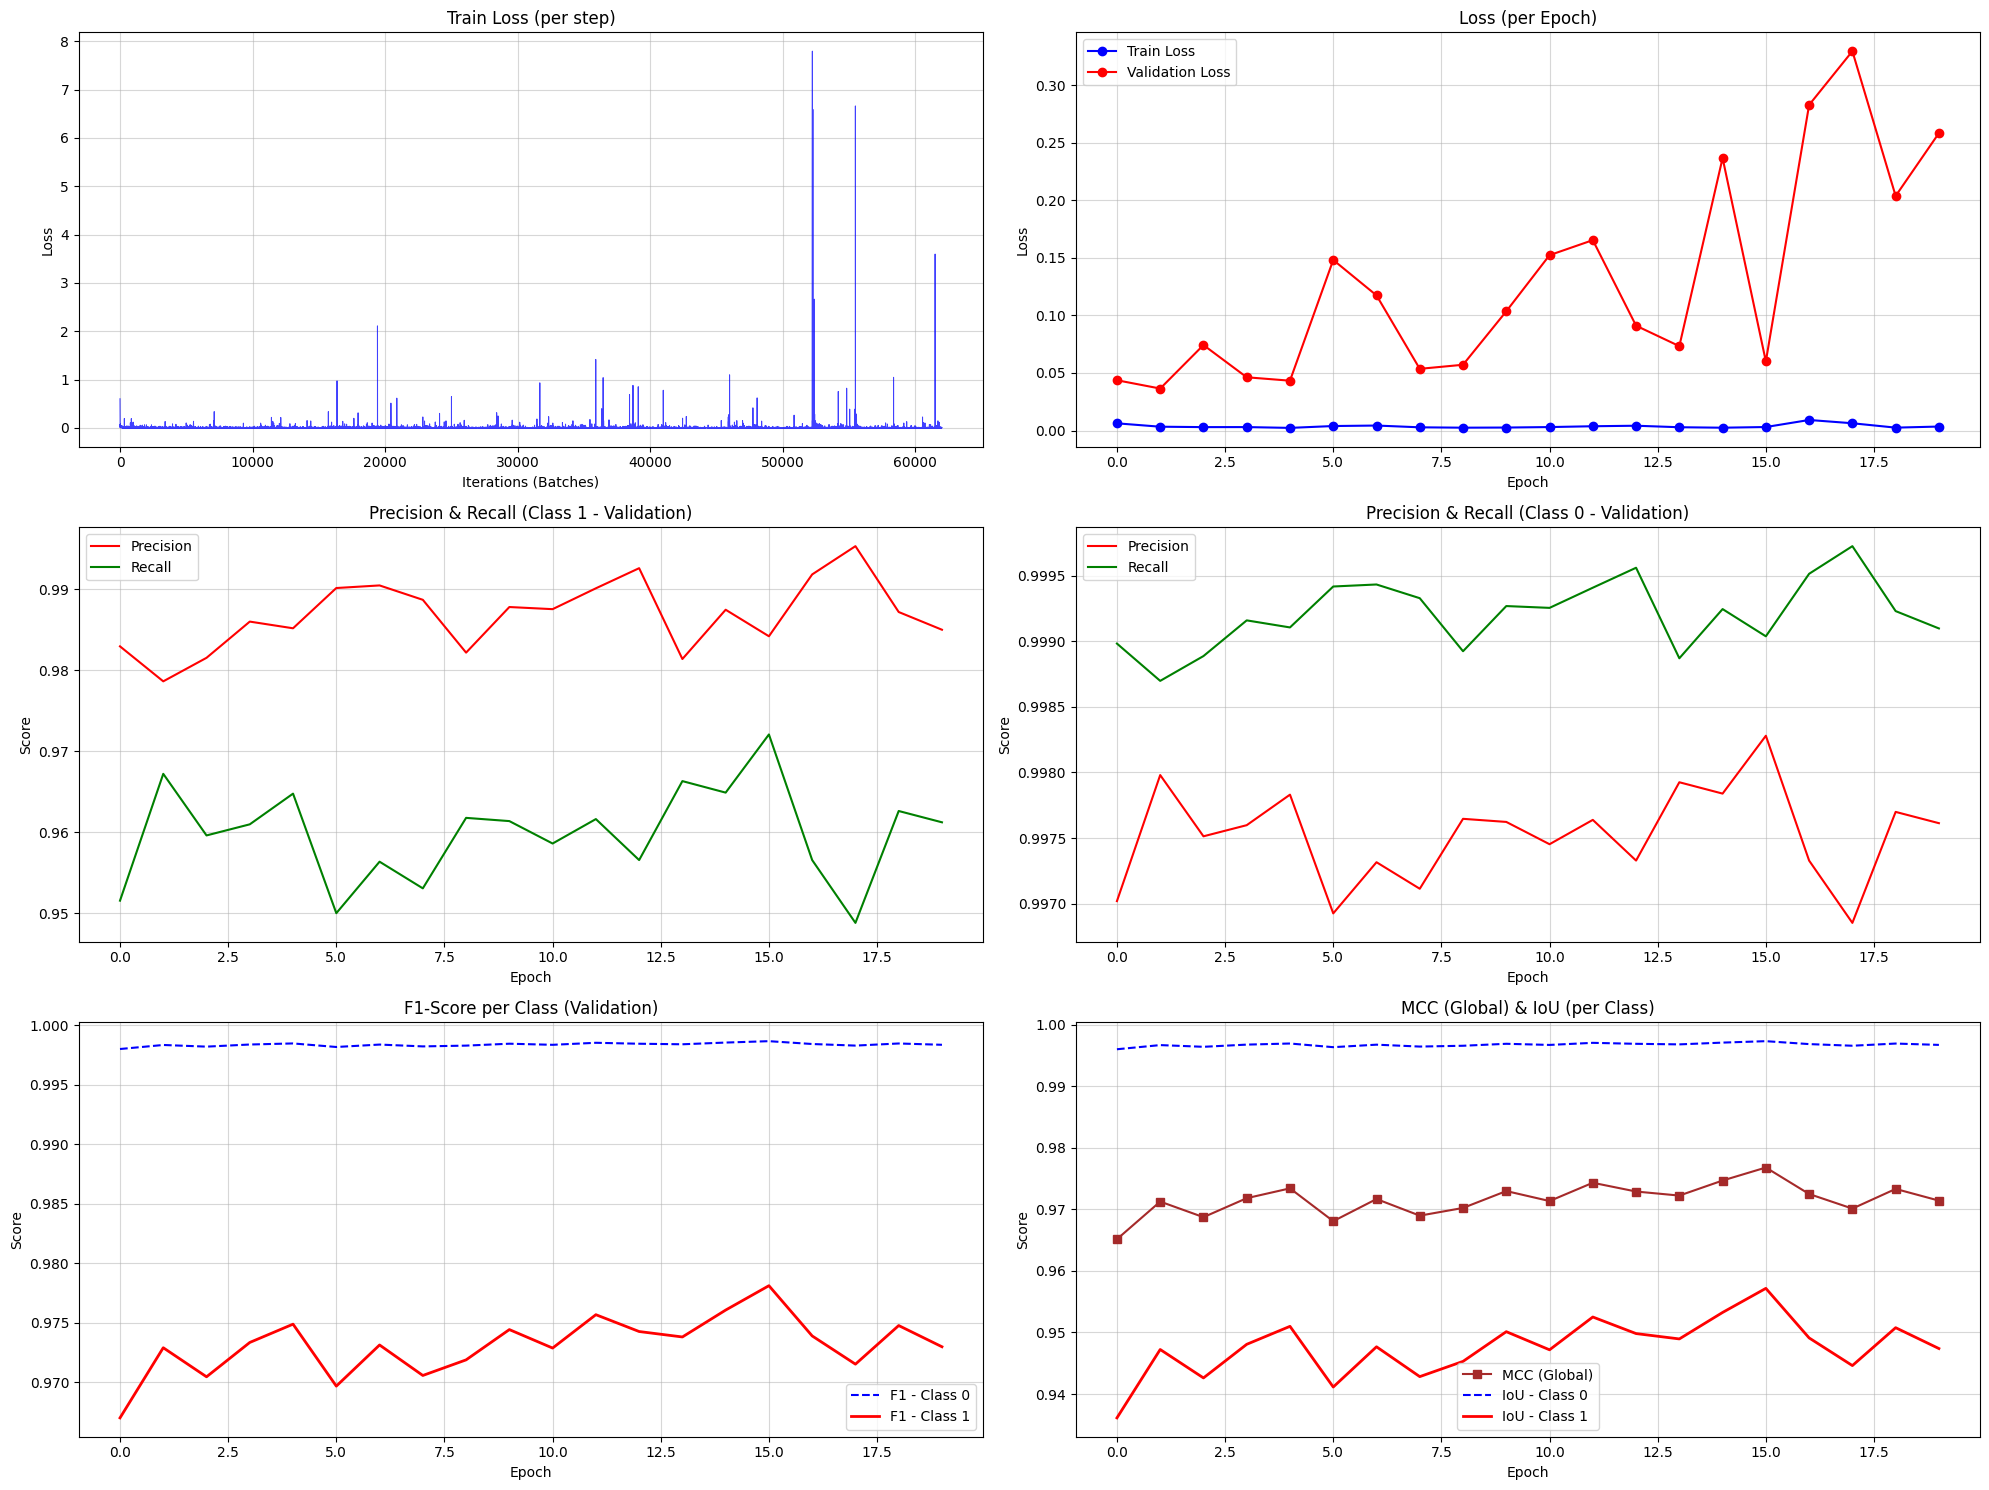

In [14]:
plot_metrics(metrics_history)

In [15]:
metrics_history, model = train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=20, batch_size=1024, device=device, display_metrics=True)

Global seed fixed on 42
Training on device: cuda (Seed: 42) | Features en entrée: 320
Start of training...
Epoch [1/20] | T.Loss: 0.0063 | V.Loss: 0.0437 | F1 (Cls 1): 0.9670 | MCC: 0.9652
Epoch [2/20] | T.Loss: 0.0033 | V.Loss: 0.0365 | F1 (Cls 1): 0.9729 | MCC: 0.9713
Epoch [3/20] | T.Loss: 0.0030 | V.Loss: 0.0743 | F1 (Cls 1): 0.9705 | MCC: 0.9687
Epoch [4/20] | T.Loss: 0.0030 | V.Loss: 0.0463 | F1 (Cls 1): 0.9733 | MCC: 0.9718
Epoch [5/20] | T.Loss: 0.0023 | V.Loss: 0.0433 | F1 (Cls 1): 0.9749 | MCC: 0.9734
Epoch [6/20] | T.Loss: 0.0039 | V.Loss: 0.1481 | F1 (Cls 1): 0.9697 | MCC: 0.9681
Epoch [7/20] | T.Loss: 0.0043 | V.Loss: 0.1174 | F1 (Cls 1): 0.9731 | MCC: 0.9717
Epoch [8/20] | T.Loss: 0.0028 | V.Loss: 0.0536 | F1 (Cls 1): 0.9706 | MCC: 0.9690
Epoch [9/20] | T.Loss: 0.0025 | V.Loss: 0.0571 | F1 (Cls 1): 0.9719 | MCC: 0.9702
Epoch [10/20] | T.Loss: 0.0026 | V.Loss: 0.1036 | F1 (Cls 1): 0.9744 | MCC: 0.9730
Epoch [11/20] | T.Loss: 0.0030 | V.Loss: 0.1523 | F1 (Cls 1): 0.9729 | M

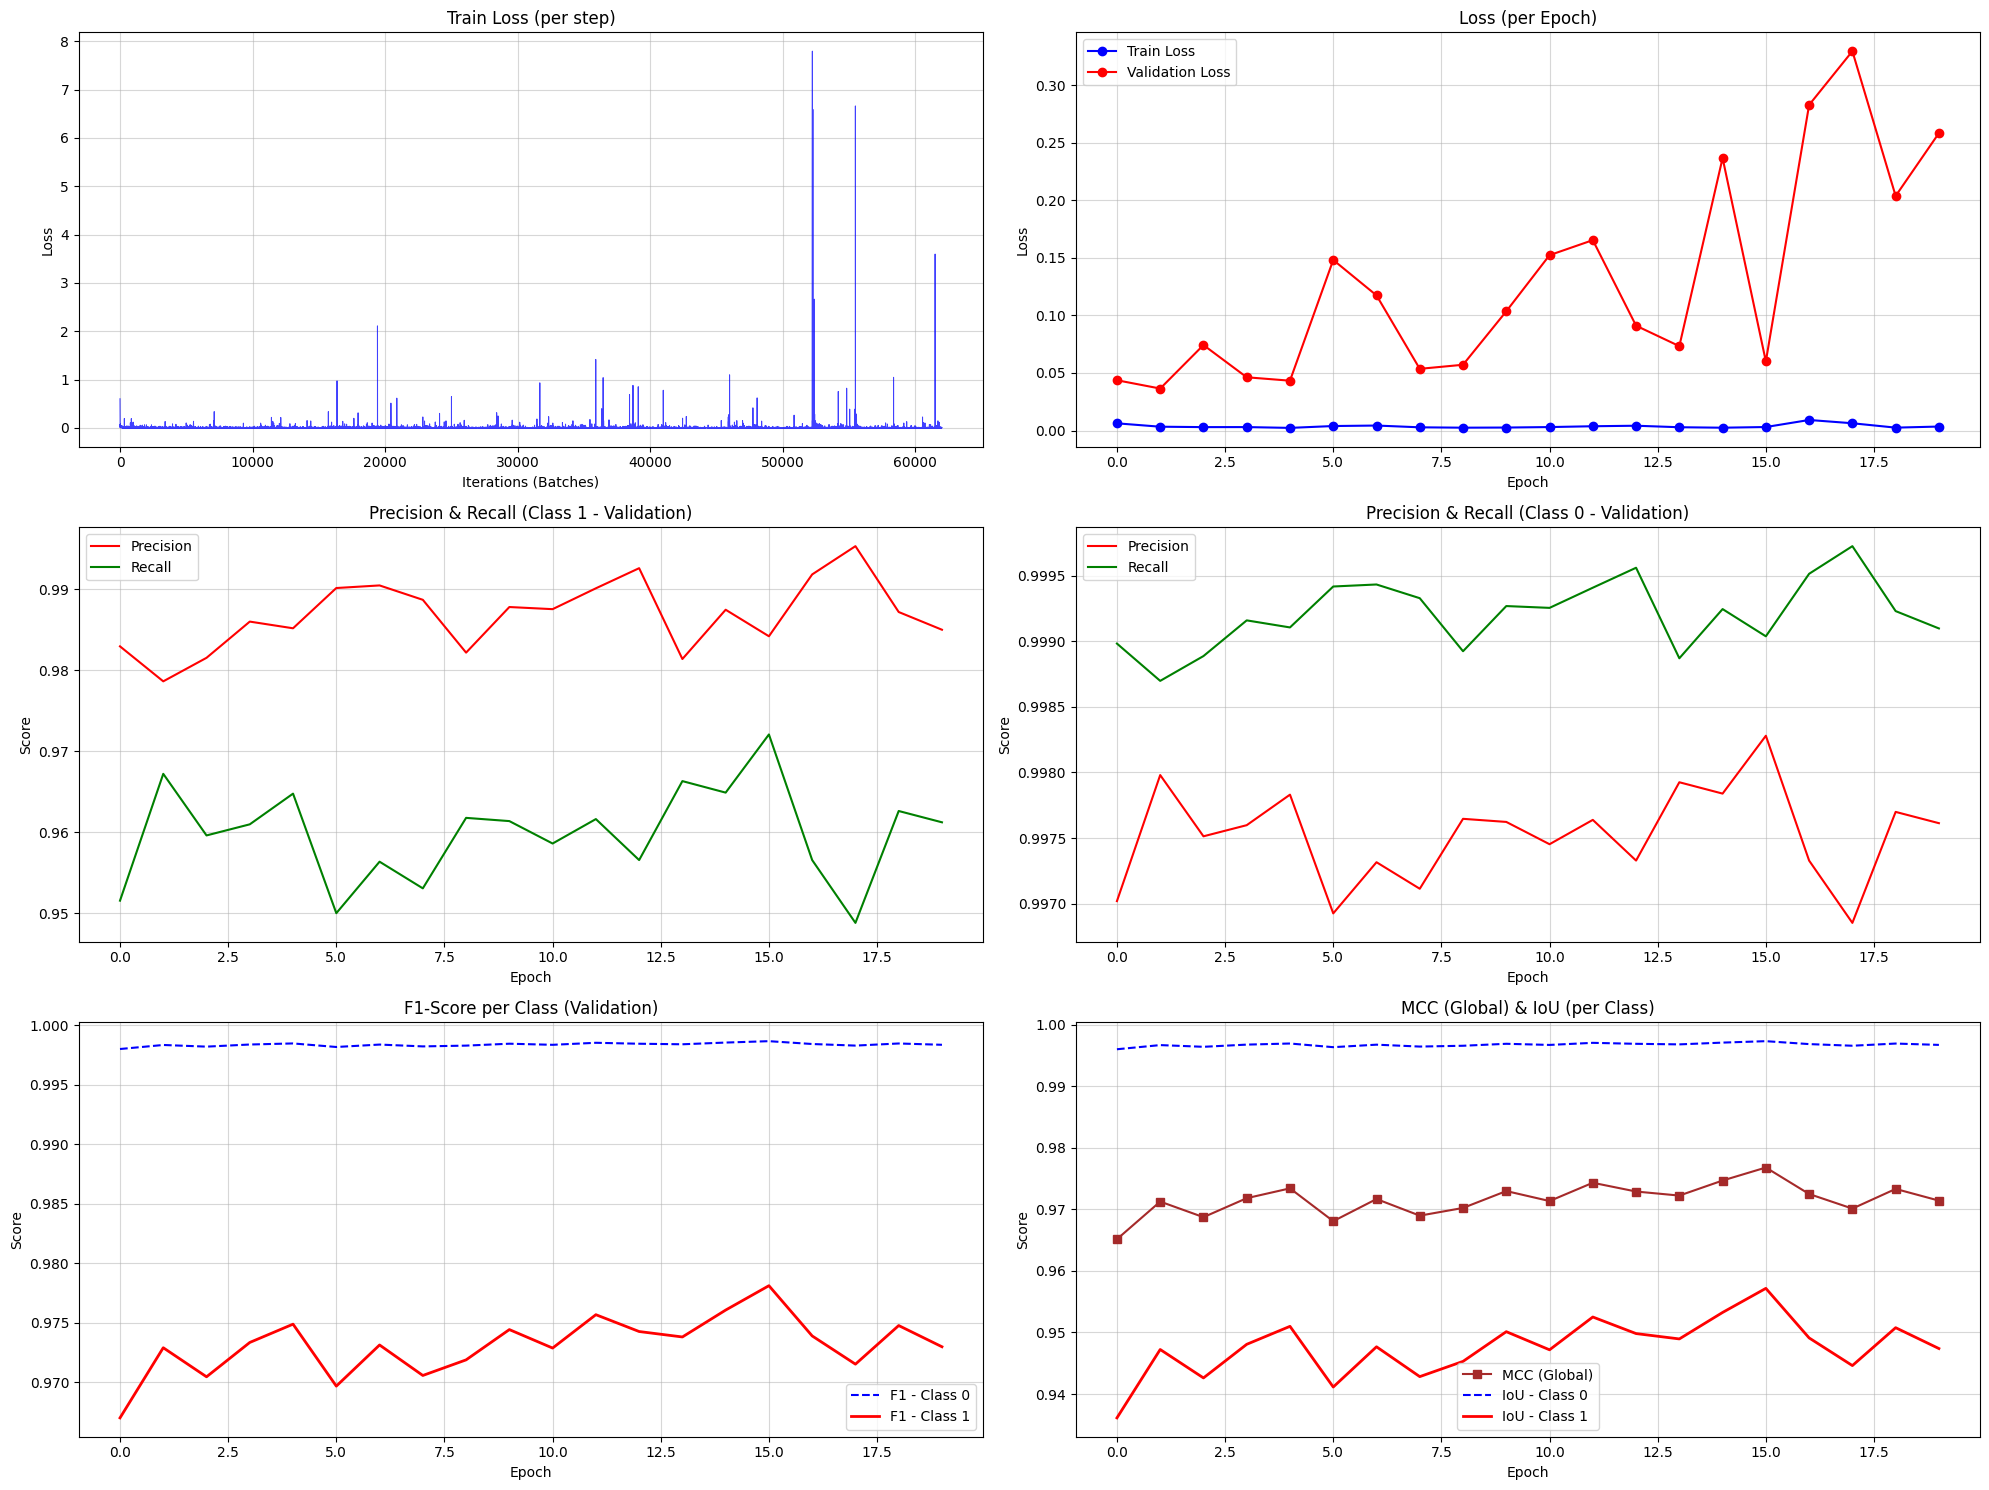

In [16]:
plot_metrics(metrics_history)